文文件旨在搞清楚陈兆庭的代码

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants, units
from meer21cm import Specification, PowerSpectrum
from meer21cm.mock import HIGalaxySimulation
from meer21cm.util import (
    center_to_edges,
    pca_clean,
    jy_to_kelvin,
    rebin_spectrum,
)
from meer21cm.plot import plot_map
from meer21cm.stack import stack, sum_3d_stack
from config import *
import warnings
from tqdm import tqdm  # 在 Jupyter 中使用更美观的版本

warnings.filterwarnings(
    "error",
    message=".*extrapolate_with_eh.*"
)

In [20]:
def mean_center_signal(signal, weights=None, los_axis=-1):
    """
    Mean-center the signal. Assume the first axis is the LOS axis.
    """
    assert len(signal.shape) == 3, "map must be 3D."
    if los_axis < 0:
        # change -1 to 2
        los_axis = 3 + los_axis
    # make sure los is the fist axis
    axes = [0, 1, 2]
    axes.remove(los_axis)
    axes = [
        los_axis,
    ] + axes
    # transpose map data
    signal = np.transpose(signal, axes=axes)
    nz, nx, ny = signal.shape
    signal = signal.reshape((nz, -1))
    if weights is not None:
        weights = np.transpose(weights, axes=axes)
        weights = weights.reshape((nz, -1))
    else:
        weights = np.ones_like(signal)
    signal = signal - np.sum(signal * weights, 1)[:, None] / np.sum(weights, 1)[:, None]
    signal = signal.reshape((nz, nx, ny))
    signal = np.transpose(signal, axes=np.argsort(axes))
    return signal


In [3]:
def weighted_covariance(signal, weights, renorm=True):
    """
    Calculate the weighted covariance matrix of the signal.

    The signal is assumed to be mean-centered, with the shape of
    (num_ch, num_pix).

    Parameters
    ----------
        signal: array.
            The input signal
        weights: array.
            The weights of each element in the signal.
        renorm: bool, default True.
            Whether to renormalize the covariance matrix
            over the sum of weights.

    Returns
    -------
        covariance: array.
            The covariance matrix of the input signal.
    """
    covariance = np.einsum("ia,ja->ij", signal * weights, signal * weights)
    if renorm:
        covariance /= np.einsum("ia,ja->ij", weights, weights)
    return covariance

In [17]:
def pca_clean(
    signal,
    N_fg,
    weights=None,
    return_analysis=False,
    mean_center=False,
    los_axis=-1,
    return_A=False,
    mean_center_weights=None,
    ignore_nan=False,
    covariance=None,
):
    r"""
    Performs PCA cleaning of the map data. If ``mean_center`` is set to ``True``,
    then the input signal is first mean-centered so that

    .. math::
        \vec{d}^{\rm mc} = \vec{d} - \langle  \vec{d} \rangle,

    where the mean of the data vector at a specific channel i is

    .. math::
        \langle \vec{d} \rangle_i = \frac{\sum_a w_{ia} d_{ia}}{\sum_a w_{ia}},

    where a loops over each sampling in channel i and :math:`w` is the weight of each element.

    A covariance matrix is then calculated on the mean-centered data

    .. math::
        C_{ij} = \frac{\sum_{a,b }w_{ia} d^{\rm mc}_{ia}
             w_{jb} d^{\rm mc}_{jb}}{\sum_{a,b }w_{ia}w_{jb}},

    over which the eigenvalue decomposition is performed.
    See Section 4.3. of MeerKLASS Collaboration 2024 [1] for more details.

    Note that, in the rigorous definition, the data vector should be zero-meaned,
    and the weights used to calculate the mean and the covariance should be the same.
    However, in practice, many people don't remove the mean of the data.
    Some use one type of weights (often just binary masks) for mean calculation, and then
    use different weights for covariance calculation. While it is not encouraged, that flexibility
    is allowed in the function, by setting a different weight ``mean_center_weights``.

    If there are frequency gaps in the data, you can set ``ignore_nan=True`` to ignore these
    channels, and treat the rest of the data as a continuous spectrum.

    Parameters
    ----------
        signal: array
            The input signal to be cleaned.
        N_fg: int.
            Number of modes to be removed.
        weights: array, default None
            The weights of each element in the signal.
            Default will set uniform weights for each element.
        return_analysis: bool, default False
            If True, instead of residual maps the function will return eigenanalysis quantities.
        mean_center: bool, default False
            Whether to mean-center the input data vector
        los_axis: int, default -1.
            Which axis is the line-of-sight, i.e. spectral axis.
        return_A: bool, default False.
            Whether to return the mixing matrix A.
        mean_center_weights: array, default None.
            The weights of each element for mean calculation.
            Default follows the ``weights`` argument.
        ignore_nan: bool, default False.
            Whether to ignore NaN values in the data.
            If True, channels with NaN values are skipped.
        covariance: array, default None.
            The covariance matrix of the input signal.
            If not provided, it will be calculated from the input signal.

    Returns
    -------
        residual: array.
            The residual after PCA cleaning.
        A: array, if ``return_A=True``.
            The mixing matrix.
        covariance: array, if ``return_analysis=True``.
            The covariance matrix of the input signal.
        eignumb: array, if ``return_analysis=True``.
            The number indexing of the eigenvalues starting from 1.
        eigenval: array, if ``return_analysis=True``.
            The eigenvalues of the covariance matrix.
        V: array, if ``return_analysis=True``.
            The eigenvectors of the covariance matrix.

    References
    ----------
    .. [1] MeerKLASS collab, "MeerKLASS L-band deep-field intensity maps: entering the HI dominated regime", https://arxiv.org/abs/2407.21626.
    """
    if mean_center:
        if mean_center_weights is None:
            signal = mean_center_signal(signal, weights, los_axis)
        else:
            signal = mean_center_signal(signal, mean_center_weights, los_axis)
    assert len(signal.shape) == 3, "map must be 3D."
    if los_axis < 0:
        # change -1 to 2
        los_axis = 3 + los_axis
    # make sure los is the fist axis
    axes = [0, 1, 2]
    axes.remove(los_axis)
    axes = [
        los_axis,
    ] + axes
    # transpose map data
    signal = np.transpose(signal, axes=axes)
    nz, nx, ny = signal.shape
    print(f"nx={nx}, ny={ny}, nz={nz}") #增
    signal = signal.reshape((nz, -1))
    if weights is not None:
        weights = np.transpose(weights, axes=axes)
        weights = weights.reshape((nz, -1))
    else:
        weights = np.ones_like(signal)

    if mean_center_weights is not None:
        mean_center_weights = np.transpose(mean_center_weights, axes=axes)
        mean_center_weights = mean_center_weights.reshape((nz, -1))
    # if mean_center:
    #    if mean_center_weights is None:
    #        signal = (
    #            signal
    #            - np.sum(signal * weights, 1)[:, None] / np.sum(weights, 1)[:, None]
    #        )
    #    else:
    #        signal = (
    #            signal
    #            - np.sum(signal * mean_center_weights, 1)[:, None]
    #            / np.sum(mean_center_weights, 1)[:, None]
    #        )
    ### Covariance calculation:
    if covariance is None:
        covariance = weighted_covariance(signal, weights)
    nan_flag = ignore_nan and np.any(np.isnan(covariance))
    if nan_flag:
        sel = np.logical_not(np.isnan(np.diagonal(covariance)))
        covariance = covariance[sel][:, sel]
        signal = np.nan_to_num(signal)
    eigenval, V = np.linalg.eigh(covariance)
    if nan_flag:
        eigenvec = np.zeros((nz, nz)) * np.nan
        eigenvec[np.where(sel)[0], -sel.sum() :] = V
        V = eigenvec
        eval = np.zeros(nz) * np.nan
        eval[-sel.sum() :] = eigenval
        eigenval = eval
    V = V[:, ::-1]  # Eigenvectors from covariance matrix with most dominant first
    if return_analysis:
        eignumb = np.linspace(1, len(eigenval), len(eigenval))
        eigenval = eigenval[::-1]  # Put largest eigenvals first
        return covariance, eignumb, eigenval, V
    A = V[:, :N_fg]  # Mixing matrix, first N_fg most dominant modes of eigenvectors
    R_pca = np.eye(nz) - A @ A.T

    # 统计全为零的列有多少
    zero_cols = np.all(signal == 0, axis=0) # 增
    num_zero_cols = np.sum(zero_cols) # 增
    print(num_zero_cols) # 增
    
    if nan_flag:
        R_pca = np.nan_to_num(R_pca)
    residual = R_pca @ signal
    residual = np.reshape(residual, (nz, nx, ny))
    residual = np.transpose(residual, axes=np.argsort(axes))
    if return_A:
        return residual, A
    return residual

In [5]:
def apply_pca_projection(
    data,
    A,
    los_axis=-1,
    ignore_nan=True,
):
    """
    用已知的 PCA mixing matrix A 对 data 做投影清洗

    参数：
    - data: 3D array (shape 与原始一致)
    - A: (N_freq, N_fg) 的 mixing matrix
    - los_axis: 频率轴
    - ignore_nan: If True, channels with NaN values are skipped.

    返回：
    - cleaned_data
    """

    # ---------- Step 1: 构造投影矩阵 ----------
    nz = A.shape[0]
    R = np.eye(nz) - A @ A.T

    # ---------- Step 2: 调整轴顺序 ----------
    if los_axis < 0:
        los_axis = data.ndim + los_axis

    axes = list(range(data.ndim))
    axes.remove(los_axis)
    axes = [los_axis] + axes

    data_t = np.transpose(data, axes=axes)
    nz_check, nx, ny = data_t.shape

    # 安全检查
    assert nz_check == nz, "A 的频率维度与 data 不匹配"

    # ---------- Step 3: reshape ----------
    data_flat = data_t.reshape((nz, -1))

    # ---------- Step 4: NaN 处理 ----------
    if ignore_nan and np.isnan(data_flat).any():
        nan_mask = np.isnan(data_flat)
        data_flat = np.nan_to_num(data_flat)
    else:
        nan_mask = None

    # ---------- Step 5: 投影 ----------
    cleaned_flat = R @ data_flat

    # ---------- Step 6: 恢复 NaN ----------
    if nan_mask is not None:
        cleaned_flat[nan_mask] = np.nan

    # ---------- Step 7: reshape 回去 ----------
    cleaned = cleaned_flat.reshape((nz, nx, ny))
    cleaned = np.transpose(cleaned, axes=np.argsort(axes))

    return cleaned

In [6]:
def cal_freq(ch_list):
    freq_list = []
    v_min = 856.0 
    v_max = 1712.0 
    dv = 0.208984375
    assert (v_max - v_min) / dv == 4096
    for ch in ch_list:
        freq_MHz = ch * dv + v_min
        freq = freq_MHz * 1e6
        freq_list.append(freq)
    freq_list = np.array(freq_list)
    return freq_list

# 频率轴计算与筛选
n_channels = 4096
freq_axis = cal_freq(np.arange(n_channels)) / 1e6  # 转为 MHz
freq_mask = (freq_axis >= 971.) & (freq_axis <= 1023.8)
Freqs = freq_axis[freq_mask]

In [7]:
sp_temp = Specification(
    map_file=fits_file,
    counts_file=counts_file,
    cosmo=cosmo,
    gal_file=gal_file,
    ra_range = ra_range_GAMA,
    dec_range = dec_range_GAMA,
    survey='meerklass_2021', 
    band='L'
)

In [8]:
ps = HIGalaxySimulation(
    map_file=fits_file,
    counts_file=counts_file,
    cosmo=cosmo,
    gal_file=gal_file,
    ra_range=ra_range_MK,
    dec_range=dec_range_MK,
    survey='meerklass_2021',
    band='L',
)

In [9]:
# 读取数据（HI map 与星系 catalog）
ps.read_from_fits()
ps.read_gal_cat()
sp_temp.read_gal_cat()


# 使用 GAMA catalog 替换 ps 内部的星系信息
ps._ra_gal = sp_temp.ra_gal
ps._dec_gal = sp_temp.dec_gal
ps._z_gal = sp_temp.z_gal

ps.ra_range = ra_range_GAMA
ps.dec_range = dec_range_GAMA
ps.ra_range = ra_range_MK
ps.dec_range = dec_range_MK

In [10]:
print(ps.data.shape)
print(np.nanmean(ps.data))

(133, 73, 252)
0.6531219954017362


In [27]:
# convert to Jy
jy_k_coeff = jy_to_kelvin(1,ps.pixel_area*(np.pi/180)**2,ps.nu)
#PCA cleaning
hi_map_clean_data,A_mat_data = pca_clean(ps.data/jy_k_coeff[None,None],10,weights=ps.W_HI,mean_center=True,return_A=True, ignore_nan = True)
R_mat_MK = np.eye(len(ps.nu))-A_mat_data@A_mat_data.T

# 打印结果并附带解释信息
np.save(save_dir + 'hi_map_clean_data', hi_map_clean_data)
np.save(save_dir + 'hi_map_dirty_data', ps.data)
np.save(save_dir + 'A_mat_data', A_mat_data)

In [12]:
temp0 = np.zeros(len(ps.nu))
R_mat_MK @ temp0

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

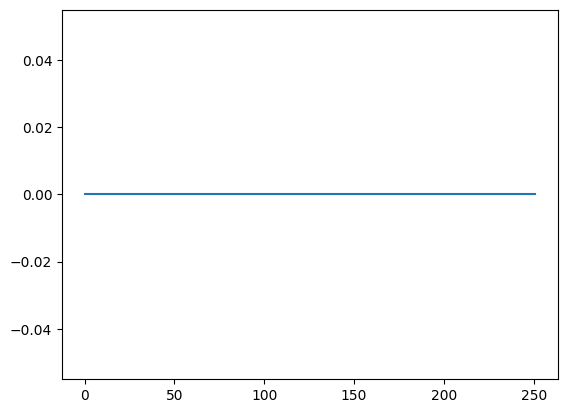

In [13]:
plt.plot(R_mat_MK @ ps.data[0,5,:])

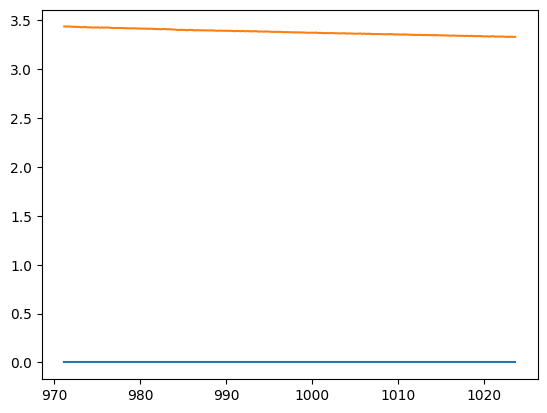

In [14]:
plt.plot(Freqs, ps.data[0,5,:])
plt.plot(Freqs, ps.data[70,35,:])

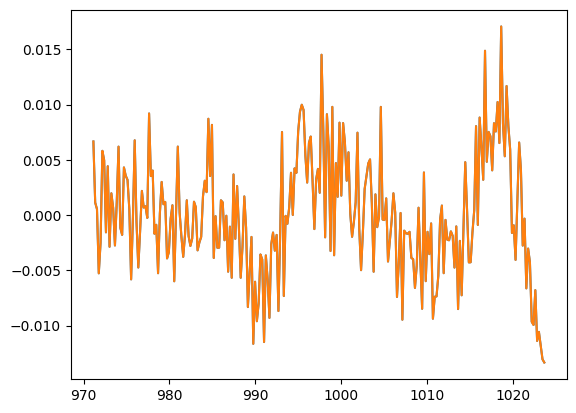

In [15]:
plt.plot(Freqs, hi_map_clean_data[0,1,:])
plt.plot(Freqs, hi_map_clean_data[130,70,:])

In [21]:
hi_map_clean_data.shape

(133, 73, 252)

In [22]:
noise = np.where(
    np.isnan(ps.data),
    np.nan,
    np.random.normal(0.0, 1.2, hi_map_clean_data.shape)
)

In [23]:
noise_cleaned = apply_pca_projection(
    noise,
    A_mat_data,
    los_axis=-1,
)

In [24]:
#stacking
stack_3D_map, stack_3D_weight = stack(
    ps,
    symmetrize=symmetrize,
)
angular_stack_osci_data,spectral_stack_osci_data = sum_3d_stack(
        stack_3D_map,ang_sum_dist=1.0/0.3
    )
spectral_stack_rebin_osci_data = rebin_spectrum(spectral_stack_osci_data)

ang_edges = np.linspace(-10,10,21)*ps.pix_resol
x_edges = np.linspace(0,2*ps.nu.size,2*ps.nu.size+1)*ps.vel_resol
x_edges -= x_edges[x_edges.size//2]
x_edges = center_to_edges(x_edges)
# x_bins
vel_bin = (x_edges[1:]+x_edges[:-1])/2
x_rebin = center_to_edges(rebin_spectrum(vel_bin))
#np.save(save_dir+'x_bins',x_rebin)
np.save(save_dir+'stack_3D_data_nosym',stack_3D_map)
np.save(save_dir+'spectral_stack_data_nosym',spectral_stack_rebin_osci_data)
#np.save(save_dir+'ang_edges',ang_edges)
np.save(save_dir+'angular_stack_data_nosym',angular_stack_osci_data)
print('start')
num_g_in_GAMA = ps.ra_gal.size

W_HI = ps.W_HI.copy()
w_HI = ps.w_HI.copy()

start


In [25]:
def one_random_sample(seed):
    hisim = HIGalaxySimulation(
        ra_range = ra_range_GAMA,
        dec_range = dec_range_GAMA,
        tracer_bias_1 = 1.5,
        tracer_bias_2 = 1.9,
        num_discrete_source = int(num_g_in_GAMA),
        seed=seed,
        downres_factor_radial=1/2,
        downres_factor_transverse=1/2,
        target_relative_to_num_g=1.5,
        kmax=15,
        nonlinear='both',
        tf_slope=3.66,
        tf_zero=1.6,
        no_vel=False,
        highres_sim=3,
        strict_num_source=True,
    )
    hisim.get_enclosing_box()
    hisim.target_relative_to_num_g = np.prod(hisim.box_len)/hisim.survey_volume * 1.2
    hisim.propagate_mock_tracer_to_gal_cat()
    sp = Specification(
        map_file=fits_file,
        counts_file=counts_file,
        cosmo=cosmo,
        gal_file=gal_file,
        ra_range = ra_range_MK,
        dec_range = dec_range_MK,
    )
    sp._data = hi_map_clean_data.copy()
    sp.W_HI = W_HI.copy()
    sp.w_HI = w_HI.copy()
    sp._ra_gal = hisim.ra_gal
    sp._dec_gal = hisim.dec_gal
    sp._z_gal = hisim.z_gal
    stack_3D_map, stack_3D_weight = stack(
        sp,
        symmetrize=symmetrize,
    )
    return stack_3D_map

In [33]:
stack_3D_rand = []

# tqdm 包裹 iterable，并指定总长度
for seed_i in tqdm(seed_list[:], desc="Processing seeds"):
    print(seed_i)
    stack_3D_i = one_random_sample(seed_i)
    stack_3D_rand.append(stack_3D_i)

# 保存结果
np.save(save_dir + 'stack_3D_rand.npy', stack_3D_rand)

#if rank == 0:
#    stack_3D_rand = []
#    for i in range(size):
#        stack_3D_rand += [np.load(save_dir+f'stack_3D_rand_{i}.npy'),]
#    stack_3D_rand = np.concatenate(*stack_3D_rand,axis=0)
#    np.save(save_dir+'stack_3D_rand',stack_3D_rand)
        

#if __name__ == "__main__":
#    stack_rand_arr = []
#    with Pool() as pool:
#        for map_i in pool.map(
#            one_random_sample,
#            seed_list
#        ):
#            stack_rand_arr += [map_i,]
#    #for seed in seed_list:
#    #    map_i = one_random_sample(seed)
#    #    stack_rand_arr += [map_i,]
#
#    stack_rand_arr = np.array(stack_rand_arr)
#    np.save(save_dir+'stack_random_pos',stack_rand_arr)



Processing seeds:   0%|          | 0/500 [00:00<?, ?it/s]

42


/users/zhaoboyan/meer21cm/src/meer21cm/grid.py:81: RuntimeWarning: Mean of empty slice.
  mean_vec = vec_arr.mean(axis=0)
/users/zhaoboyan/.conda/envs/meer21cm/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
Processing seeds:   0%|          | 0/500 [00:07<?, ?it/s]
Exception ignored in: <function tqdm.__del__ at 0x795d49840a60>
Traceback (most recent call last):
  File "/users/zhaoboyan/.conda/envs/meer21cm/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/users/zhaoboyan/.conda/envs/meer21cm/lib/python3.10/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


ValueError: zero-size array to reduction operation minimum which has no identity